In [7]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [8]:
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')

mpl.rc('font', family='TH Sarabun New', size=14)

In [9]:
with open('../election-stations-2569.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# หาหน่วยเลือกตั้งของจังหวัด
rayong = next((p for p in data['provinces'] if p['name'] == 'ระยอง'), None)
# print(f"ระยอง {rayong['total_stations']} หน่วยเลือกตั้ง")
d = dict()
sd2d = dict()
t = 0
# หาหน่วยเลือกตั้งจากรหัส
def find_total_station(area,province):
    for p in data['provinces']:
        if p['name'] == province:
            for a in p['areas']:
                if a['area'] == area:
                    for unit in a['stations']:
                        if unit['district'] not in d:
                            d[unit['district']] = dict()
                        if unit['subdistrict'] not in  d[unit['district']]:
                            d[unit['district']][unit['subdistrict']] = 1
                            sd2d[unit['subdistrict']] = unit['district']
                        else:
                            d[unit['district']][unit['subdistrict']] += 1
    return None

find_total_station(2, 'ลำปาง')
print(d)
print(sd2d)
for k, v in d.items():
    for e, g in v.items():
        t+=g
print(t)

d['นอกเขต'] = dict()
for i in range(1,14):
    sub_dist = f"ชุดที่ {i}"
    sd2d[sub_dist] = 'นอกเขต'
    d['นอกเขต'][sub_dist] = 1
    # all_subdistrict.append(sub_dist)

d['วังเหนือ']['บ้านใหม่'] = 4
d['วังเหนือ']['วังเหนือ'] = 8
d['แจ้ห่ม']['แจ้ห่ม(ในเขต)'] = 6
d['แจ้ห่ม']['แจ้ห่ม(นอกเขต)'] = 8
d['แจ้ห่ม'].pop('แจ้ห่ม', None)
sd2d['บ้านใหม่'] = 'วังเหนือ'
sd2d['แจ้ห่ม(ในเขต)'] = "แจ้ห่ม"
sd2d['แจ้ห่ม(นอกเขต)'] = "แจ้ห่ม"

all_distrcit = []
all_subdistrict = []
district_count = {}
for k,v in d.items():
    all_distrcit.append(k)
    all_subdistrict += v.keys()
    for key in v.keys():
        if k not in district_count:
            district_count[k] = v[key]
        else: district_count[k]+= v[key]

{'เมืองลำปาง': {'บ้านแลง': 12, 'บ้านเสด็จ': 19}, 'งาว': {'หลวงเหนือ': 7, 'หลวงใต้': 8, 'บ้านโป่ง': 12, 'บ้านร้อง': 13, 'ปงเตา': 13, 'นาแก': 6, 'บ้านอ้อน': 8, 'บ้านแหง': 9, 'บ้านหวด': 7, 'แม่ตีบ': 7}, 'แจ้ห่ม': {'แจ้ห่ม': 14, 'บ้านสา': 10, 'ปงดอน': 9, 'แม่สุก': 12, 'เมืองมาย': 7, 'ทุ่งผึ้ง': 8, 'วิเชตนคร': 12}, 'วังเหนือ': {'ทุ่งฮั้ว': 12, 'วังเหนือ': 12, 'วังใต้': 7, 'ร่องเคาะ': 18, 'วังทอง': 9, 'วังซ้าย': 10, 'วังแก้ว': 7, 'วังทรายคำ': 9}, 'เมืองปาน': {'เมืองปาน': 11, 'บ้านขอ': 14, 'ทุ่งกว๋าว': 16, 'แจ้ซ้อน': 15, 'หัวเมือง': 9}}
{'บ้านแลง': 'เมืองลำปาง', 'บ้านเสด็จ': 'เมืองลำปาง', 'หลวงเหนือ': 'งาว', 'หลวงใต้': 'งาว', 'บ้านโป่ง': 'งาว', 'บ้านร้อง': 'งาว', 'ปงเตา': 'งาว', 'นาแก': 'งาว', 'บ้านอ้อน': 'งาว', 'บ้านแหง': 'งาว', 'บ้านหวด': 'งาว', 'แม่ตีบ': 'งาว', 'แจ้ห่ม': 'แจ้ห่ม', 'บ้านสา': 'แจ้ห่ม', 'ปงดอน': 'แจ้ห่ม', 'แม่สุก': 'แจ้ห่ม', 'เมืองมาย': 'แจ้ห่ม', 'ทุ่งผึ้ง': 'แจ้ห่ม', 'วิเชตนคร': 'แจ้ห่ม', 'ทุ่งฮั้ว': 'วังเหนือ', 'วังเหนือ': 'วังเหนือ', 'วังใต้': 'วังเหนือ', 'ร่องเคาะ': 'วังเ

In [10]:
series_all_district = pd.Series(all_distrcit)
series_all_subdistrict = pd.Series(all_subdistrict)

# Data Extraction

In [11]:
url = "https://www.thaiphc.net/phc/phcadmin/administrator/Report/OSMRP000VHV.php"
init_body = {
    "provinceid": 52,
    "ampurid": "",
    "tambonid": "",
    "search": "ออกรายงาน" 
}

In [12]:
response = requests.post(url=url, data=init_body)
response.encoding = 'tis-620'

In [13]:
if response.status_code == 200:
    html = response.text

In [14]:
district2id = dict()
sub_district2val = dict()

In [15]:
soup = BeautifulSoup(html, "lxml")
for district in all_distrcit:
    option = soup.select_one(f"option:-soup-contains('{district}')")
    if option:
        val = option.get("value")
        district2id[district] = val
    else:
        district2id[district] = -1

In [16]:
all_subdistrict.append("แจ้ห่ม")

In [17]:
for district, id in district2id.items():
    if id == -1:continue
    print(district)
    init_body['ampurid'] = int(id)
    response = requests.post(url=url, data=init_body)
    response.encoding = 'tis-620'
    if response.status_code == 200:
        html = response.text
        soup = BeautifulSoup(html, "lxml")
        tables = soup.select("tr>td.tableb")
        for i, row in enumerate(tables):
            a = row.select_one("a")
            if a and a.text.strip() in all_subdistrict:
                record = tables[i+1:i+6]
                sub_district2val[a.text.strip()] = dict()
                sub_district2val[a.text.strip()]['สมัครเป็นจิตอาสาแล้ว'] = int(record[0].text.strip())
                sub_district2val[a.text.strip()]['จะสมัครเป็นจิตอาส'] = int(record[1].text.strip())
                sub_district2val[a.text.strip()]['ยังไม่พร้อมเป็นจิตอาสา'] = int(record[2].text.strip())
                sub_district2val[a.text.strip()]['ยังไม่ได้เลือกสถานะจิตอาสา'] = int(record[3].text.strip())
                sub_district2val[a.text.strip()]['จำนวนจิตอาสารวม'] = int(record[4].text.strip())
    else:
        print(f"Something went wrong with code: {response.status_code}")

เมืองลำปาง
งาว
แจ้ห่ม
วังเหนือ
เมืองปาน


In [18]:
for sd in all_subdistrict:
    if sd not in sub_district2val and "ชุดที่" not in sd and "แจ้ห่ม" not in sd:
        sub_district2val[sd] = dict()
        sub_district2val[sd]['สมัครเป็นจิตอาสาแล้ว'] = -1
        sub_district2val[sd]['จะสมัครเป็นจิตอาส'] = -1
        sub_district2val[sd]['ยังไม่พร้อมเป็นจิตอาสา'] = -1
        sub_district2val[sd]['ยังไม่ได้เลือกสถานะจิตอาสา'] = -1
        sub_district2val[sd]['จำนวนจิตอาสารวม'] = -1

In [19]:
df_osm = pd.DataFrame(sub_district2val).T
df_osm.to_csv("../master_osmpertumbon.csv")

In [20]:
print(df_osm.shape)

(33, 5)


In [21]:
index2remove = df_osm.loc[df_osm['จำนวนจิตอาสารวม'] == -1, :].index.tolist()
df_osm = df_osm.drop(index2remove, axis=0)
print(df_osm.shape)

(32, 5)


In [22]:
df_osm.index

Index(['บ้านแลง', 'บ้านเสด็จ', 'นาแก', 'บ้านโป่ง', 'บ้านร้อง', 'บ้านหวด',
       'บ้านแหง', 'บ้านอ้อน', 'ปงเตา', 'แม่ตีบ', 'หลวงใต้', 'หลวงเหนือ',
       'แจ้ห่ม', 'ทุ่งผึ้ง', 'บ้านสา', 'ปงดอน', 'เมืองมาย', 'แม่สุก',
       'วิเชตนคร', 'ทุ่งฮั้ว', 'ร่องเคาะ', 'วังแก้ว', 'วังซ้าย', 'วังใต้',
       'วังทรายคำ', 'วังทอง', 'วังเหนือ', 'แจ้ซ้อน', 'ทุ่งกว๋าว', 'บ้านขอ',
       'เมืองปาน', 'หัวเมือง'],
      dtype='str')

# Data Preparation

In [23]:
import pandas as pd
df_results = pd.read_csv("../master_result_clean.csv")
df_results.head(10)

,type,province,district,sub-district,unit_number,name,score,score_clean
0,บช,ลำปาง,นอกเขต,ชุดที่ 1,-1,ไทยทรัพย์ทวี,0,0
1,บช,ลำปาง,นอกเขต,ชุดที่ 1,-1,เพื่อชาติไทย,6,6
2,บช,ลำปาง,นอกเขต,ชุดที่ 1,-1,ใหม่,4,4
3,บช,ลำปาง,นอกเขต,ชุดที่ 1,-1,มิติใหม่,0,0
4,บช,ลำปาง,นอกเขต,ชุดที่ 1,-1,รวมใจไทย,1,1
5,บช,ลำปาง,นอกเขต,ชุดที่ 1,-1,รวมไทยสร้างชาติ,9,9
6,บช,ลำปาง,นอกเขต,ชุดที่ 1,-1,พลวัต,1,1
7,บช,ลำปาง,นอกเขต,ชุดที่ 1,-1,ประชาธิปไตยใหม่,1,1
8,บช,ลำปาง,นอกเขต,ชุดที่ 1,-1,เพื่อไทย,6,6
9,บช,ลำปาง,นอกเขต,ชุดที่ 1,-1,ทางเลือกใหม่,3,3


In [24]:
results_groupby = df_results.groupby(['sub-district', 'name'])['score_clean'].sum().unstack("name")

In [25]:
cols = results_groupby.columns.tolist()

In [26]:
df_1 = pd.read_csv("../master_summary.csv", index_col=0)
mannual_index = df_1.loc[df_1['valid_ballots'] == -1, :].index.tolist()
mannual_sd = df_1.loc[df_1['valid_ballots'] == -1, ['type', 'unit_number', 'district', 'sub-district']].values.tolist()

In [27]:
for l in mannual_sd:
    valid_ball = df_results[(df_results['type'] == l[0]) & (df_results['unit_number'] == l[1]) & (df_results['district'] == l[2]) & (df_results['sub-district'] == l[3])]['score_clean'].sum()
    df_1.loc[(df_1['type'] == l[0]) & (df_1['unit_number'] == l[1]) & (df_1['district'] == l[2]) & (df_1['sub-district'] == l[3]), 'valid_ballots'] = valid_ball

In [28]:
df_1.loc[df_1['valid_ballots'] == -1, :]

,type,province,district,sub-district,unit_number,total_ballots,valid_ballots,invalid_ballots,no_vote_ballots,remain_ballots


In [29]:
df_1.to_csv("../master_summary_clean.csv", index=False)

In [30]:
results_groupby

name,กรีน,กล้าธรรม,ก้าวอิสระ,ครูไทยเพื่อประชาชน,คลองไทย,ความหวังใหม่,ทางเลือกใหม่,ท้องที่ไทย,นางสาววิชุดา ว่องวัฒนวิโรจน์,นางสาวสุวิภา กุศลจูง,...,ไทยก้าวใหม่,ไทยชนะ,ไทยทรัพย์ทวี,ไทยธรรม,ไทยพร้อม,ไทยพิทักษ์ธรรม,ไทยภักดี,ไทยรวมไทย,ไทยสร้างไทย,ไทรวมพลัง
sub-district,,,,,,,,,,,,,,,,,,,,,
ชุดที่ 1,0,6,0,1,0,0,3,0,20,459,...,0,0,0,0,0,0,1,0,1,0
ชุดที่ 10,0,5,0,0,1,0,2,0,15,450,...,1,0,0,1,0,0,0,0,4,0
ชุดที่ 11,0,12,1,0,0,0,2,0,20,425,...,2,0,0,0,0,0,0,1,5,0
ชุดที่ 12,80,8,0,0,1,0,4,0,16,452,...,0,0,0,0,1,0,0,0,2,0
ชุดที่ 13,0,4,0,0,0,0,2,0,16,434,...,2,0,0,0,0,0,0,0,4,0
ชุดที่ 2,0,6,0,1,0,0,3,1,14,444,...,0,0,2,0,0,0,2,0,0,0
ชุดที่ 3,0,0,0,0,0,0,4,6,25,488,...,0,0,0,0,0,0,1,0,0,0
ชุดที่ 4,1,9,2,0,0,0,2,0,18,463,...,1,0,0,0,0,0,0,0,3,1
ชุดที่ 5,0,8,0,1,0,0,2,0,18,461,...,1,0,1,0,0,0,0,0,1,0


In [31]:
index2have = df_osm.index.tolist()
results_groupby = results_groupby.rename(index={'แจ้ห่ม(ในเขต)':"แจ้ห่ม"})
results_groupby = results_groupby[results_groupby.index.isin(index2have)]

In [32]:
index2have

['บ้านแลง',
 'บ้านเสด็จ',
 'นาแก',
 'บ้านโป่ง',
 'บ้านร้อง',
 'บ้านหวด',
 'บ้านแหง',
 'บ้านอ้อน',
 'ปงเตา',
 'แม่ตีบ',
 'หลวงใต้',
 'หลวงเหนือ',
 'แจ้ห่ม',
 'ทุ่งผึ้ง',
 'บ้านสา',
 'ปงดอน',
 'เมืองมาย',
 'แม่สุก',
 'วิเชตนคร',
 'ทุ่งฮั้ว',
 'ร่องเคาะ',
 'วังแก้ว',
 'วังซ้าย',
 'วังใต้',
 'วังทรายคำ',
 'วังทอง',
 'วังเหนือ',
 'แจ้ซ้อน',
 'ทุ่งกว๋าว',
 'บ้านขอ',
 'เมืองปาน',
 'หัวเมือง']

In [33]:
for ind in index2have:
    if ind not in results_groupby.index.tolist():
        print(ind)

In [52]:
df_1khet = df_1.loc[df_1['type'] == 'เขต'].groupby('sub-district')['valid_ballots'].sum()
df_1party = df_1.loc[df_1['type'] == 'บช'].groupby('sub-district')['valid_ballots'].sum()

In [35]:
df_1khet = df_1khet.rename(index={'แจ้ห่ม(ในเขต)':"แจ้ห่ม"})
df_1party = df_1party.rename(index={'แจ้ห่ม(ในเขต)':"แจ้ห่ม"})

In [36]:
results_groupby['valid_ballots_khet'] = df_1khet
results_groupby['valid_ballots_party'] = df_1party

In [37]:
results_groupby['อสม'] = df_osm['จำนวนจิตอาสารวม']
results_groupby

name,กรีน,กล้าธรรม,ก้าวอิสระ,ครูไทยเพื่อประชาชน,คลองไทย,ความหวังใหม่,ทางเลือกใหม่,ท้องที่ไทย,นางสาววิชุดา ว่องวัฒนวิโรจน์,นางสาวสุวิภา กุศลจูง,...,ไทยธรรม,ไทยพร้อม,ไทยพิทักษ์ธรรม,ไทยภักดี,ไทยรวมไทย,ไทยสร้างไทย,ไทรวมพลัง,valid_ballots_khet,valid_ballots_party,อสม
sub-district,,,,,,,,,,,,,,,,,,,,,
ทุ่งกว๋าว,3,322,5,4,12,2,22,4,93,1328,...,28,16,4,16,4,14,2,4465,4529,261
ทุ่งผึ้ง,3,90,1,2,8,0,12,3,63,517,...,1,6,0,6,2,5,3,2219,2281,125
ทุ่งฮั้ว,5,332,2,7,33,2,15,11,168,949,...,4,8,1,4,1,11,5,2955,2954,179
นาแก,0,366,0,4,2,1,6,2,30,356,...,2,3,8,4,0,10,3,1741,1779,105
บ้านขอ,2,235,1,11,10,6,15,6,119,1391,...,11,16,4,10,3,27,2,3603,3816,216
บ้านร้อง,1,496,4,4,10,66,12,6,55,637,...,10,9,0,6,1,13,3,2843,2914,200
บ้านสา,1,102,3,5,6,1,18,1,128,985,...,4,5,0,9,1,8,0,2587,2675,134
บ้านหวด,5,179,4,2,4,0,9,1,78,535,...,3,4,0,3,1,5,2,2024,2034,111
บ้านอ้อน,3,384,0,3,4,1,13,2,62,476,...,3,5,1,2,1,7,5,2104,2113,103


In [38]:
people_names = [
    "นางสาววิชุดา ว่องวัฒนวิโรจน์",
    "นางสาวสุวิภา กุศลจูง",
    "นายศรีพรหม หอมยก",
    "นายสมบูรณ์ รูปสะอาด",
    "นายดาชัย เอกปฐพี",
    "นายธนาธร โล่ห์สุนทร",
    "พันเอกสันทัด ภัทรกิตตินนท์",
]
party2number = dict()
with open("../partys_lists_number.txt", 'r', encoding="utf-8") as f:
    party_names = []
    for line in f:
        if line.strip() == "":continue
        num, party = line.strip().split(":")
        num = int(num.strip().split()[1])
        party = party.strip().removeprefix("พรรค")
        party_names.append(party)
        party2number[party] = num
for i in range(1,8):
    party2number[people_names[i-1]] = i

In [51]:
df_partynpeople = pd.DataFrame(list(party2number.items()), columns=['Name', 'Number']).set_index("Name")
df_partynpeople.to_csv("../master_names_partynpeople.csv")

In [39]:
results_groupby[people_names] = results_groupby[people_names].div(results_groupby['valid_ballots_khet'], axis=0)
results_groupby[party_names] = results_groupby[party_names].div(results_groupby['valid_ballots_party'], axis=0)
results_groupby["อสม_normalize"] = results_groupby['อสม']/1000

In [40]:
results_groupby

name,กรีน,กล้าธรรม,ก้าวอิสระ,ครูไทยเพื่อประชาชน,คลองไทย,ความหวังใหม่,ทางเลือกใหม่,ท้องที่ไทย,นางสาววิชุดา ว่องวัฒนวิโรจน์,นางสาวสุวิภา กุศลจูง,...,ไทยพร้อม,ไทยพิทักษ์ธรรม,ไทยภักดี,ไทยรวมไทย,ไทยสร้างไทย,ไทรวมพลัง,valid_ballots_khet,valid_ballots_party,อสม,อสม_normalize
sub-district,,,,,,,,,,,,,,,,,,,,,
ทุ่งกว๋าว,0.000662,0.071097,0.001104,0.000883,0.002650,0.000442,0.004858,0.000883,0.020829,0.297424,...,0.003533,0.000883,0.003533,0.000883,0.003091,0.000442,4465,4529,261,0.261
ทุ่งผึ้ง,0.001315,0.039456,0.000438,0.000877,0.003507,0.000000,0.005261,0.001315,0.028391,0.232988,...,0.002630,0.000000,0.002630,0.000877,0.002192,0.001315,2219,2281,125,0.125
ทุ่งฮั้ว,0.001693,0.112390,0.000677,0.002370,0.011171,0.000677,0.005078,0.003724,0.056853,0.321151,...,0.002708,0.000339,0.001354,0.000339,0.003724,0.001693,2955,2954,179,0.179
นาแก,0.000000,0.205734,0.000000,0.002248,0.001124,0.000562,0.003373,0.001124,0.017231,0.204480,...,0.001686,0.004497,0.002248,0.000000,0.005621,0.001686,1741,1779,105,0.105
บ้านขอ,0.000524,0.061583,0.000262,0.002883,0.002621,0.001572,0.003931,0.001572,0.033028,0.386067,...,0.004193,0.001048,0.002621,0.000786,0.007075,0.000524,3603,3816,216,0.216
บ้านร้อง,0.000343,0.170213,0.001373,0.001373,0.003432,0.022649,0.004118,0.002059,0.019346,0.224059,...,0.003089,0.000000,0.002059,0.000343,0.004461,0.001030,2843,2914,200,0.200
บ้านสา,0.000374,0.038131,0.001121,0.001869,0.002243,0.000374,0.006729,0.000374,0.049478,0.380750,...,0.001869,0.000000,0.003364,0.000374,0.002991,0.000000,2587,2675,134,0.134
บ้านหวด,0.002458,0.088004,0.001967,0.000983,0.001967,0.000000,0.004425,0.000492,0.038538,0.264328,...,0.001967,0.000000,0.001475,0.000492,0.002458,0.000983,2024,2034,111,0.111
บ้านอ้อน,0.001420,0.181732,0.000000,0.001420,0.001893,0.000473,0.006152,0.000947,0.029468,0.226236,...,0.002366,0.000473,0.000947,0.000473,0.003313,0.002366,2104,2113,103,0.103


In [41]:
# รวมคอลัมน์ที่ต้องการเช็ค
df_final = results_groupby[people_names + party_names + ['อสม_normalize']]
df_final.head()

name,นางสาววิชุดา ว่องวัฒนวิโรจน์,นางสาวสุวิภา กุศลจูง,นายศรีพรหม หอมยก,นายสมบูรณ์ รูปสะอาด,นายดาชัย เอกปฐพี,นายธนาธร โล่ห์สุนทร,พันเอกสันทัด ภัทรกิตตินนท์,ไทยทรัพย์ทวี,เพื่อชาติไทย,ใหม่,...,ไทยก้าวใหม่,ประชาอาสาชาติ,พร้อม,เครือข่ายชาวนาแห่งประเทศไทย,ไทยพิทักษ์ธรรม,ความหวังใหม่,ไทยรวมไทย,เพื่อบ้านเมือง,พลังไทยรักชาติ,อสม_normalize
sub-district,,,,,,,,,,,,,,,,,,,,,
ทุ่งกว๋าว,0.020829,0.297424,0.015230,0.012766,0.370885,0.128779,0.118253,0.009274,0.034886,0.006403,...,0.002208,0.000883,0.000883,0.000442,0.000883,0.000442,0.000883,0.001325,0.001546,0.261
ทุ่งผึ้ง,0.028391,0.232988,0.008112,0.011717,0.309599,0.336187,0.033348,0.008768,0.032004,0.003946,...,0.003507,0.000438,0.000877,0.000000,0.000000,0.000000,0.000877,0.002630,0.002192,0.125
ทุ่งฮั้ว,0.056853,0.321151,0.021997,0.007107,0.392217,0.224027,0.013875,0.010156,0.031483,0.009140,...,0.001016,0.001016,0.000339,0.002708,0.000339,0.000677,0.000339,0.001016,0.000339,0.179
นาแก,0.017231,0.204480,0.023550,0.008616,0.590465,0.151063,0.005744,0.004497,0.030916,0.007307,...,0.001124,0.000000,0.001124,0.001124,0.004497,0.000562,0.000000,0.001686,0.000562,0.105
บ้านขอ,0.033028,0.386067,0.030808,0.016098,0.200111,0.276991,0.056897,0.018606,0.056080,0.004717,...,0.002096,0.000262,0.001834,0.001048,0.001048,0.001572,0.000786,0.001048,0.006027,0.216


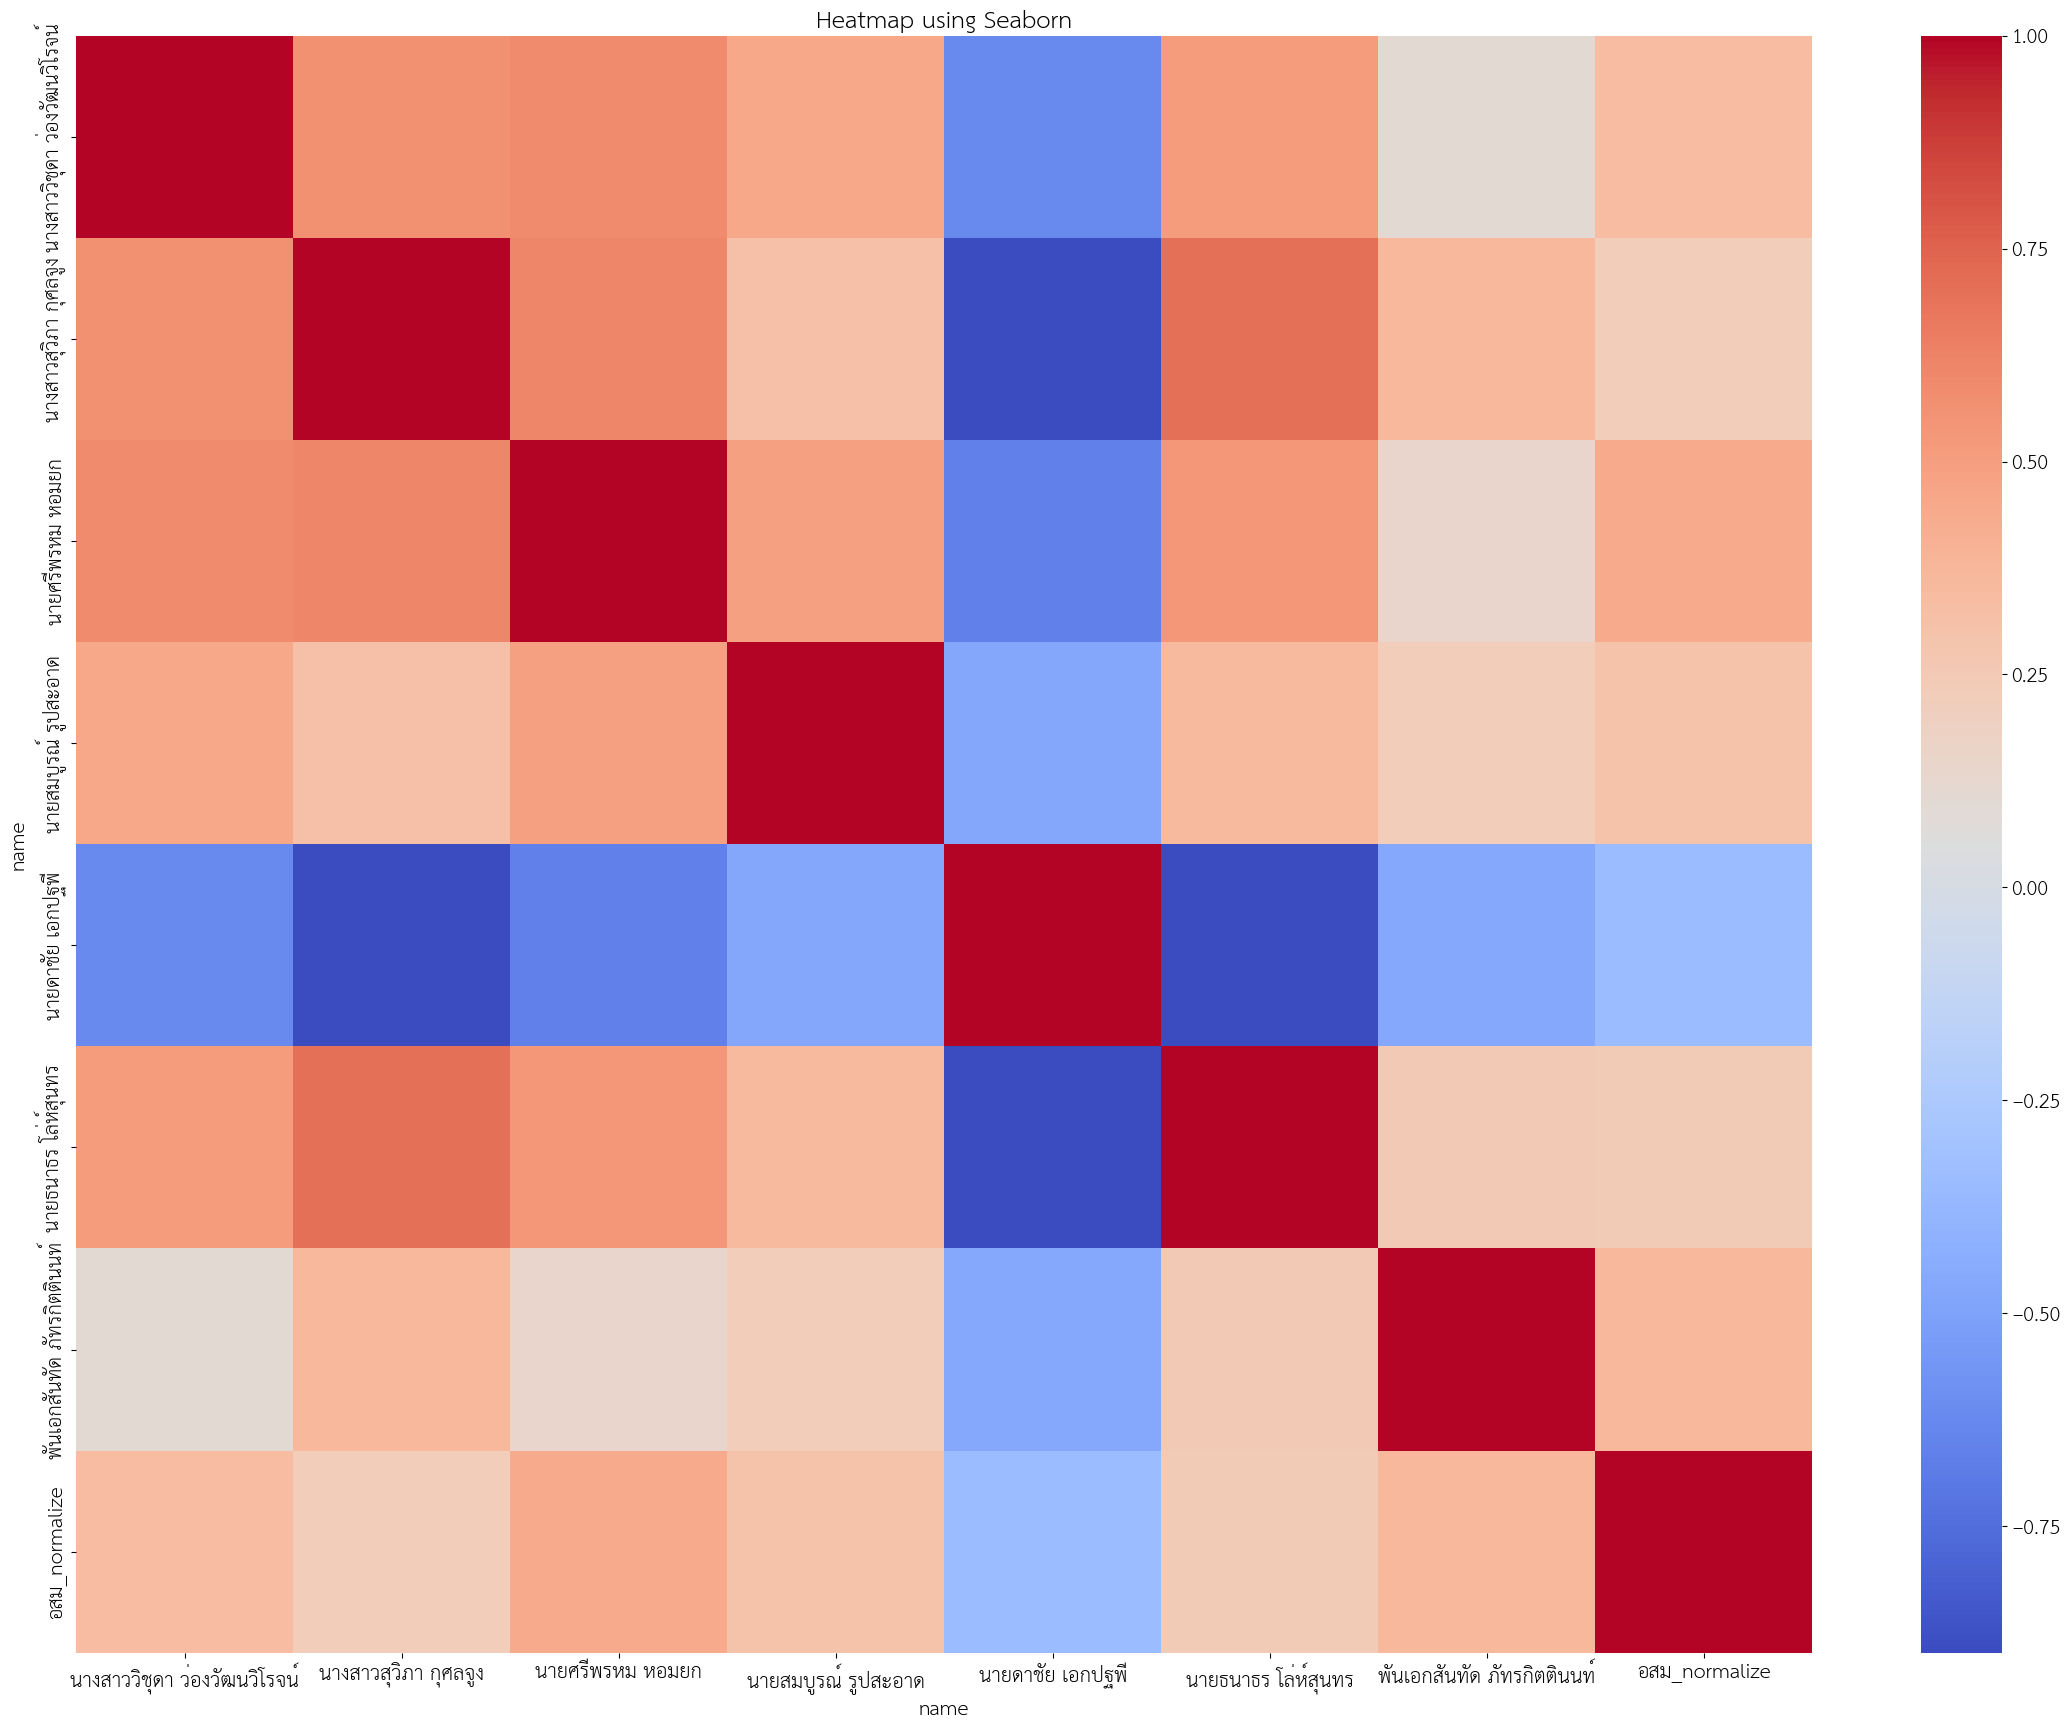

In [42]:
plt.figure(figsize=(28,21))

sns.heatmap(df_final[people_names + ["อสม_normalize"]].corr(),cmap='coolwarm')

plt.title("Heatmap using Seaborn")
plt.show()

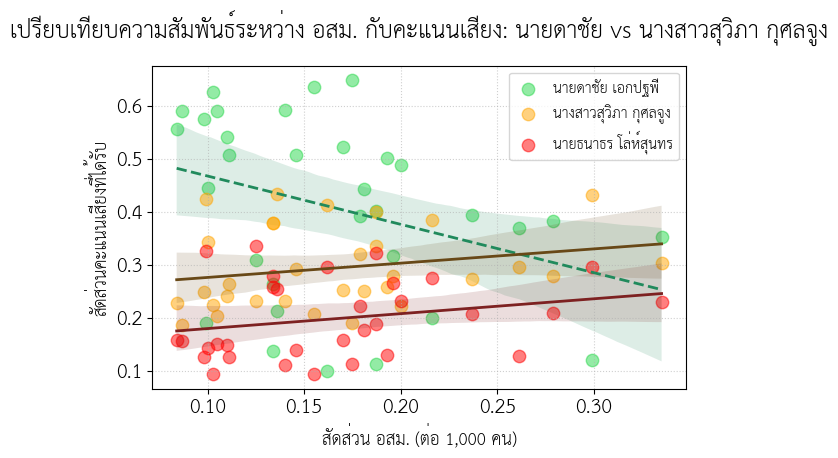

In [43]:
sns.regplot(
    data=results_groupby, 
    x='อสม_normalize', 
    y='นายดาชัย เอกปฐพี',
    label='นายดาชัย เอกปฐพี',
    scatter_kws={'s': 80, 'alpha': 0.5, 'color': "#29D84C"},
    line_kws={'color': "#208A5C", 'linestyle': '--', 'linewidth': 2}
)

# 3. พล็อตคนที่สอง: นางสาวสุวิภา (ใช้สีส้ม-เขียว)
sns.regplot(
    data=results_groupby, 
    x='อสม_normalize', 
    y=people_names[1], # นางสาวสุวิภา กุศลจูง
    label=people_names[1],
    scatter_kws={'s': 80, 'alpha': 0.5, 'color': '#FFA500'}, # สีส้ม
    line_kws={'color': "#684817", 'linestyle': '-', 'linewidth': 2}  # สีเขียว
)

sns.regplot(
    data=results_groupby, 
    x='อสม_normalize', 
    y=people_names[5],
    label=people_names[5],
    scatter_kws={'s': 80, 'alpha': 0.5, 'color': "#FF0000"}, # สีส้ม
    line_kws={'color': "#7D2121", 'linestyle': '-', 'linewidth': 2}  # สีเขียว
)
# # 4. วนลูปใส่ชื่อตำบล (แนะนำให้เลือกใส่แค่คนเดียวเพื่อไม่ให้รก หรือใส่ตรงกลางระหว่าง 2 จุด)
# for idx, row in results_groupby.iterrows():
#     # คำนวณค่าเฉลี่ย Y ของทั้งสองคนเพื่อให้ชื่อตำบลอยู่ตรงกลางระหว่างจุดสองจุด
#     y_mean = (row['นายดาชัย เอกปฐพี'] + row[people_names[1]]) / 2
#     plt.text(
#         x=row['อสม_normalize'] + 0.002, 
#         y=y_mean, 
#         s=idx, 
#         fontsize=8, 
#         alpha=0.7,
#         verticalalignment='center'
#     )

# 5. ตกแต่งรายละเอียด
plt.title('เปรียบเทียบความสัมพันธ์ระหว่าง อสม. กับคะแนนเสียง: นายดาชัย vs ' + people_names[1], fontsize=16, pad=20)
plt.xlabel('สัดส่วน อสม. (ต่อ 1,000 คน)', fontsize=12)
plt.ylabel('สัดส่วนคะแนนเสียงที่ได้รับ', fontsize=12)

# เพิ่ม Legend เพื่อบอกว่าสีไหนคือใคร
plt.legend(loc='upper right', fontsize=10)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

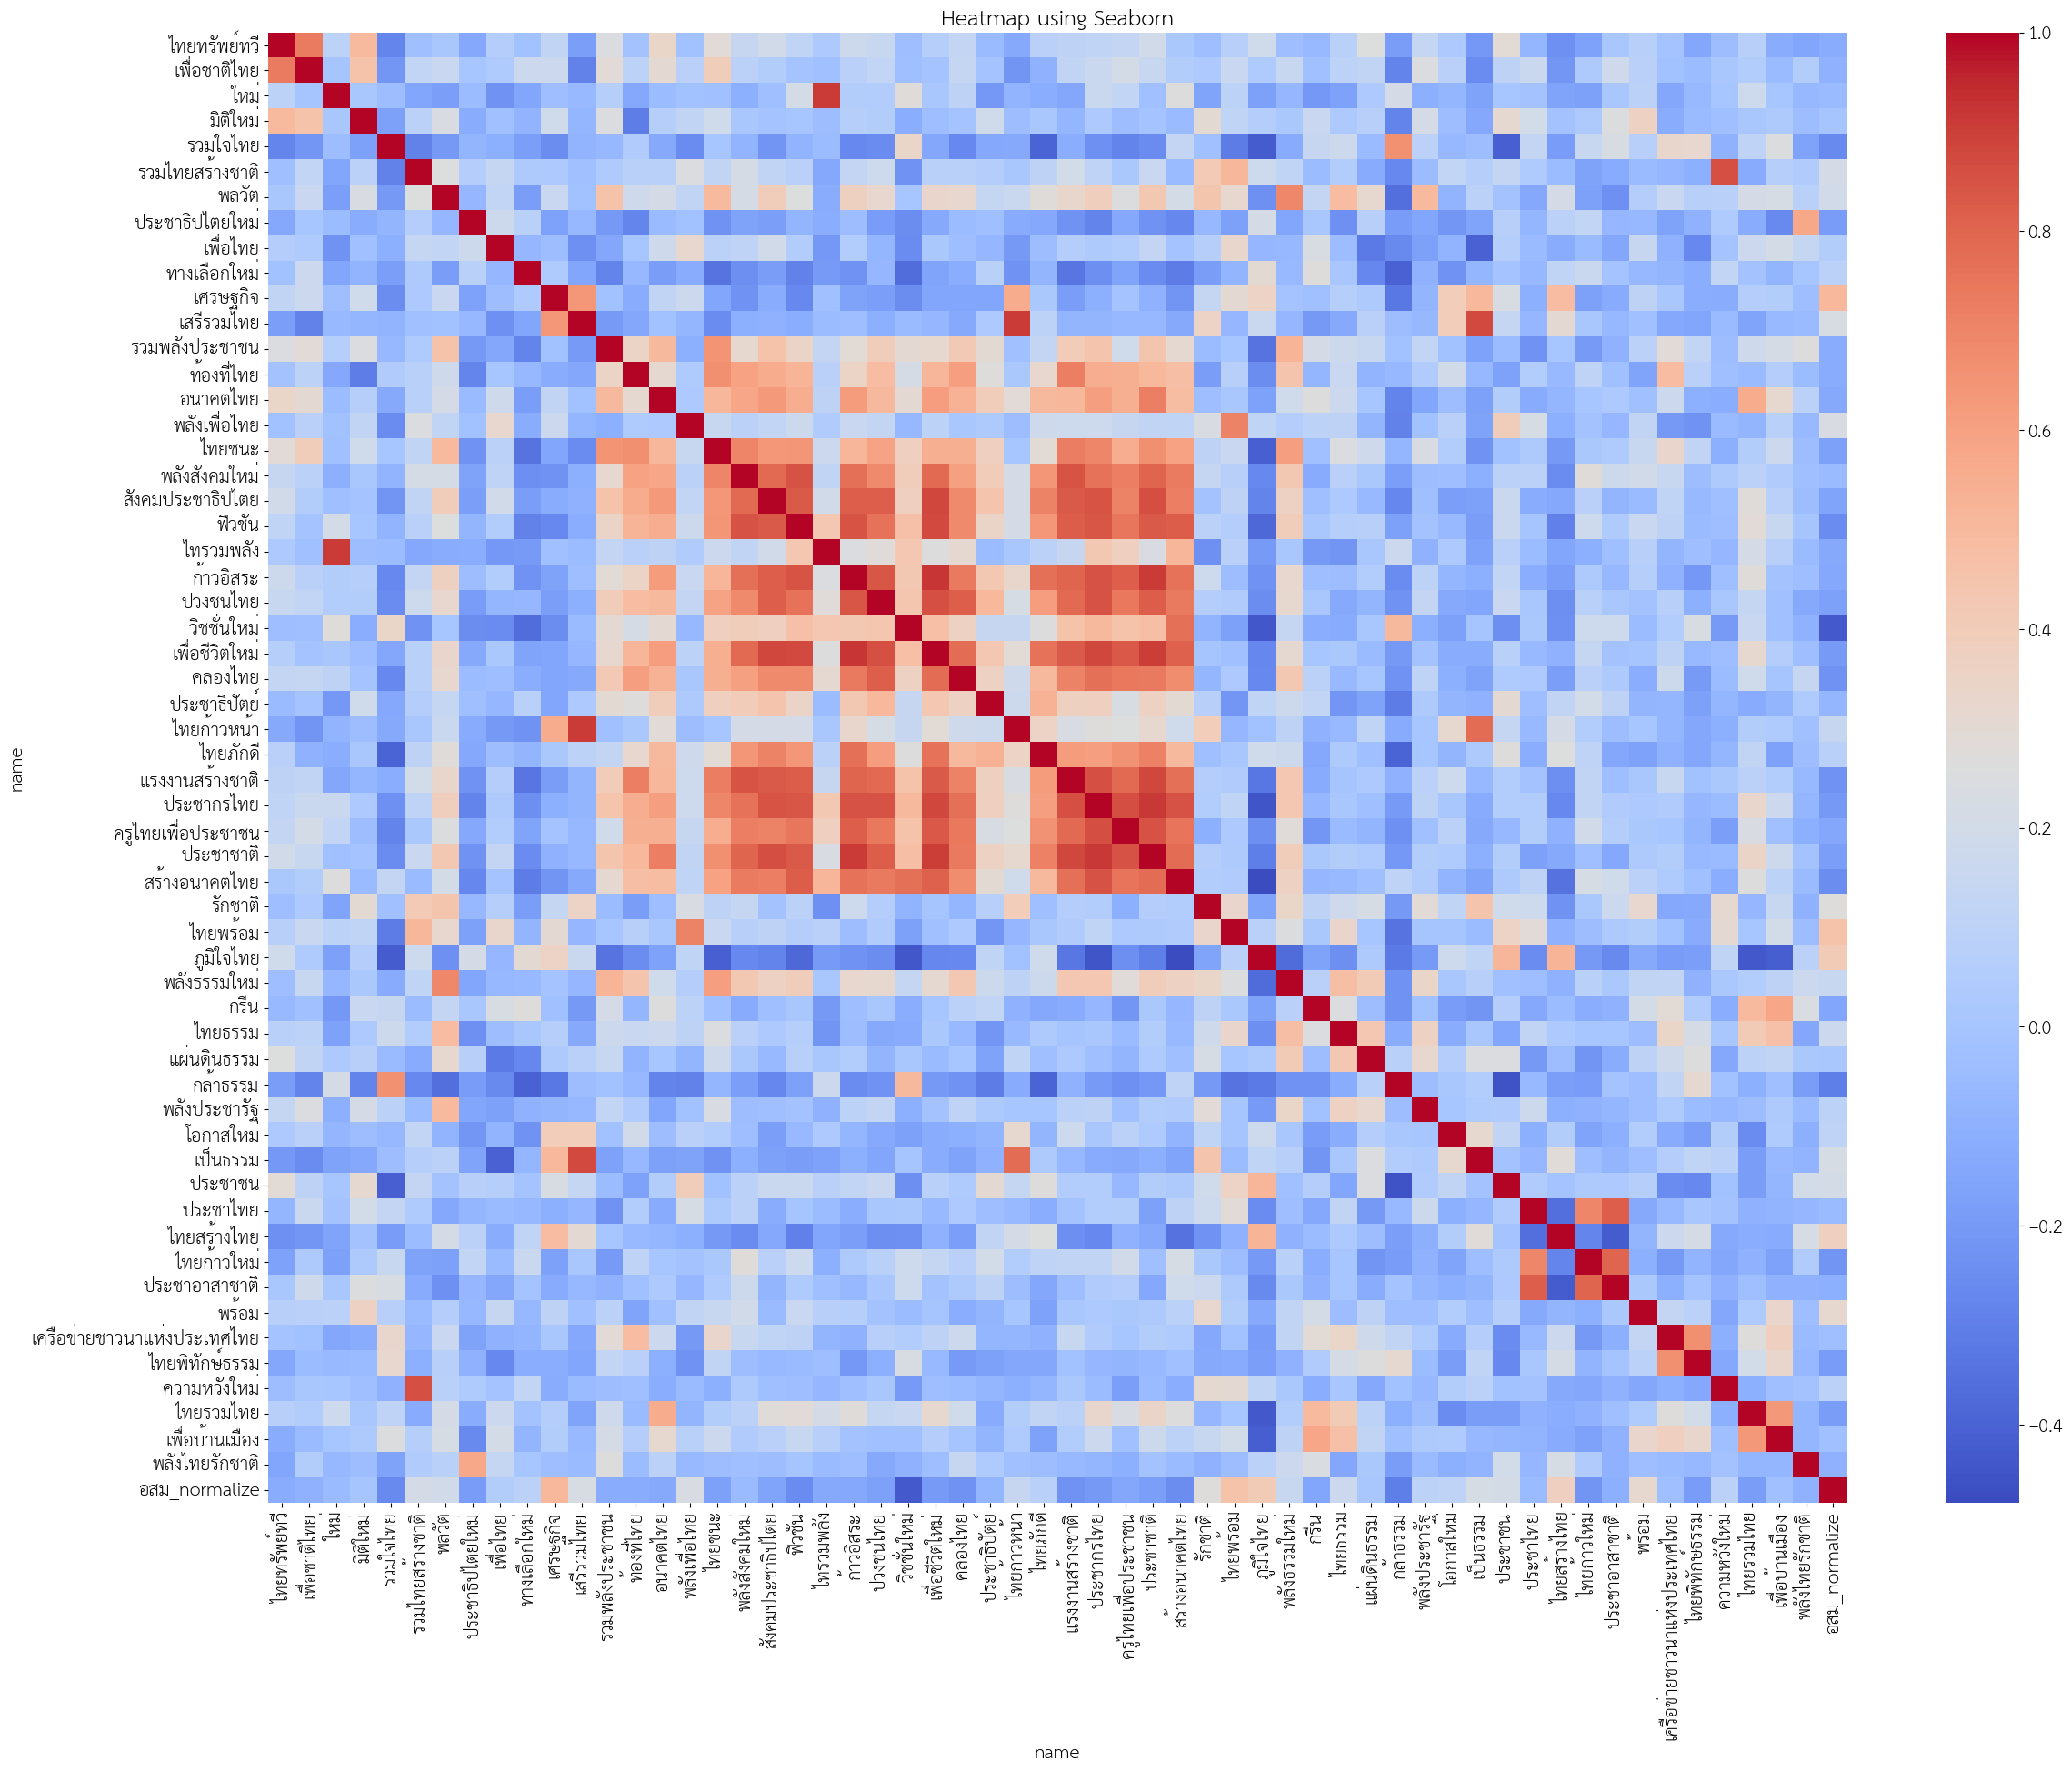

In [44]:
plt.figure(figsize=(28,21))

sns.heatmap(df_final[party_names + ["อสม_normalize"]].corr(),cmap='coolwarm')

plt.title("Heatmap using Seaborn")
plt.show()